# Drug Review Dataset — Exploratory Data Analysis

This notebook explores the UCI Drug Review dataset before modeling. We will:
- Understand the structure and size of the data
- Identify data quality issues
- Visualize condition and rating distributions
- Select the top 20 conditions for classification

In [1]:
!pip3 install pandas matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import html
import re
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

train_df = pd.read_csv('/content/drive/MyDrive/nlp-project/archive/drugsComTrain_raw.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/nlp-project/archive/drugsComTest_raw.csv')

Mounted at /content/drive


In [4]:

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head(3)

Train shape: (161297, 7)
Test shape:  (53766, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17


## 2. Basic Statistics

In [5]:
print('=== TRAIN SET ===')
print(train_df.dtypes)
print()
print('Null values:')
print(train_df.isnull().sum())
print()
print(f'Duplicate reviews: {train_df["review"].duplicated().sum()}')
print(f'Unique drugs:      {train_df["drugName"].nunique()}')
print(f'Unique conditions: {train_df["condition"].nunique()}')
print(f'Rating range:      {train_df["rating"].min()} – {train_df["rating"].max()}')

=== TRAIN SET ===
uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object

Null values:
uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

Duplicate reviews: 48968
Unique drugs:      3436
Unique conditions: 884
Rating range:      1 – 10


## 3. Data Quality Issues

In [6]:
# Empty condition labels
empty_cond = train_df['condition'].isna() | (train_df['condition'].str.strip() == '')
print(f'Rows with empty condition: {empty_cond.sum()}')

# Malformed condition labels (contain digits — likely HTML artifacts)
malformed = train_df['condition'].str.contains(r'\d', regex=True, na=False)
print(f'Malformed condition labels: {malformed.sum()}')
print('\nExamples of malformed conditions:')
print(train_df.loc[malformed, 'condition'].value_counts().head(10))

# HTML entities in reviews
has_html = train_df['review'].str.contains(r'&[a-z]+;|&#\d+;', regex=True, na=False)
print(f'\nReviews containing HTML entities: {has_html.sum()}')
print('Example:', train_df.loc[has_html, 'review'].iloc[0][:200])

Rows with empty condition: 899
Malformed condition labels: 3617

Examples of malformed conditions:
condition
Diabetes, Type 2                              2554
Diabetes, Type 1                               140
0</span> users found this comment helpful.     104
2</span> users found this comment helpful.      85
3</span> users found this comment helpful.      84
1</span> users found this comment helpful.      83
4</span> users found this comment helpful.      66
6</span> users found this comment helpful.      46
5</span> users found this comment helpful.      40
7</span> users found this comment helpful.      37
Name: count, dtype: int64

Reviews containing HTML entities: 105310
Example: "I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not availab


## 4. Condition Distribution

In [7]:
# Filter out malformed/empty conditions for analysis
valid = train_df[train_df['condition'].notna() & ~train_df['condition'].str.contains(r'\d', regex=True, na=False)]
condition_counts = valid['condition'].value_counts()

print(f'Total valid conditions: {len(condition_counts)}')
print(f'Total valid reviews:    {len(valid)}')
print()
print('Top 20 conditions:')
print(condition_counts.head(20).to_string())

Total valid conditions: 806
Total valid reviews:    156781

Top 20 conditions:
condition
Birth Control                28788
Depression                    9069
Pain                          6145
Anxiety                       5904
Acne                          5588
Bipolar Disorde               4224
Insomnia                      3673
Weight Loss                   3609
Obesity                       3568
ADHD                          3383
Emergency Contraception       2463
High Blood Pressure           2321
Vaginal Yeast Infection       2274
Abnormal Uterine Bleeding     2096
Bowel Preparation             1859
ibromyalgia                   1791
Smoking Cessation             1780
Migraine                      1694
Anxiety and Stress            1663
Major Depressive Disorde      1607


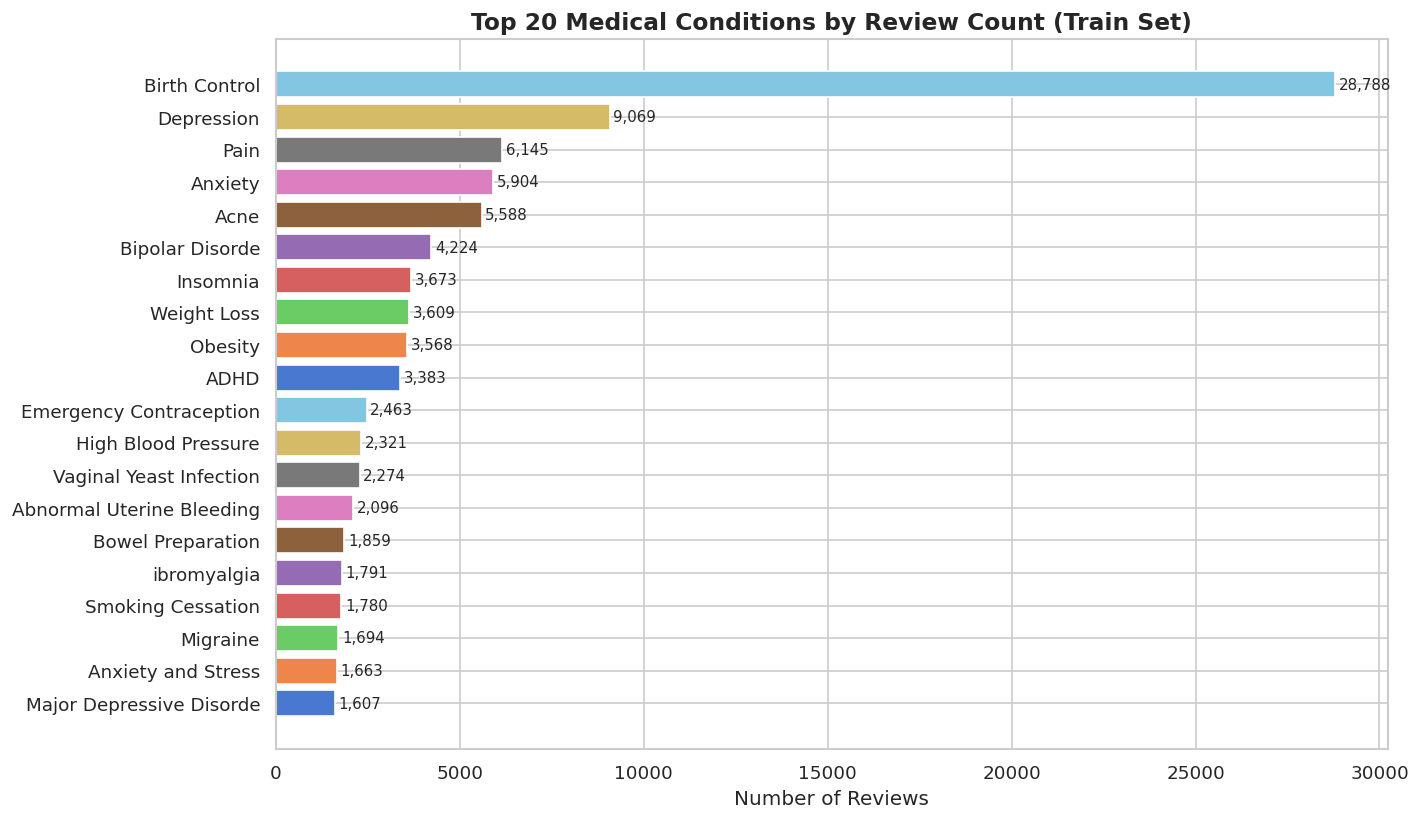

Saved: eda_top20_conditions.png


In [8]:
top20 = condition_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=sns.color_palette('muted', 20))
ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_title('Top 20 Medical Conditions by Review Count (Train Set)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nlp-project/eda_top20_conditions.png', bbox_inches='tight')
plt.show()
print('Saved: eda_top20_conditions.png')

In [9]:
# Coverage: what % of reviews do the top 20 cover?
total_valid = len(valid)
top20_total = top20.sum()
print(f'Top 20 conditions cover {top20_total:,} / {total_valid:,} reviews ({top20_total/total_valid*100:.1f}%)')

# Long tail
for t in [10, 50, 100]:
    rare = (condition_counts < t).sum()
    print(f'Conditions with < {t:3} reviews: {rare} ({rare/len(condition_counts)*100:.1f}%)')

Top 20 conditions cover 93,499 / 156,781 reviews (59.6%)
Conditions with <  10 reviews: 396 (49.1%)
Conditions with <  50 reviews: 581 (72.1%)
Conditions with < 100 reviews: 659 (81.8%)


## 5. Rating Distribution

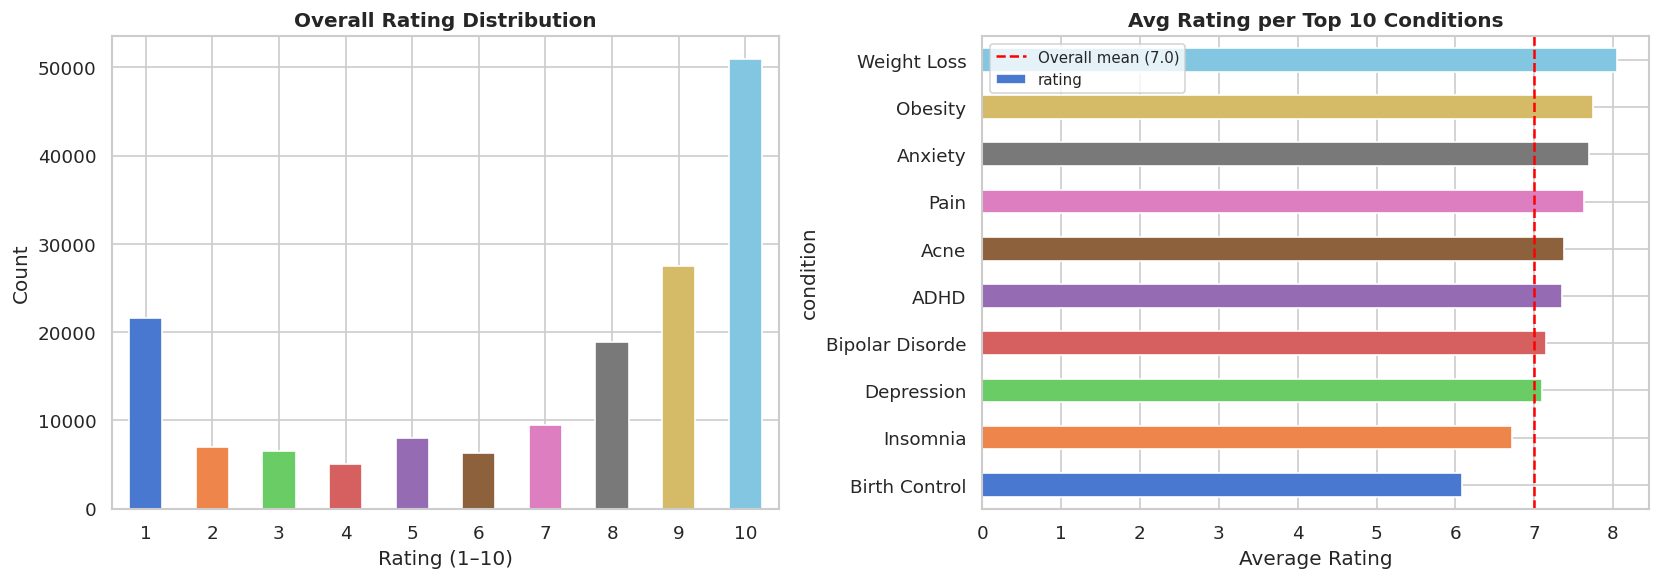

Saved: eda_ratings.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=sns.color_palette('muted', 10), edgecolor='white')
axes[0].set_title('Overall Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating (1–10)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

top10_names = condition_counts.head(10).index.tolist()
avg_rating = valid[valid['condition'].isin(top10_names)].groupby('condition')['rating'].mean().reindex(top10_names)
avg_rating.sort_values().plot(kind='barh', ax=axes[1], color=sns.color_palette('muted', 10))
axes[1].set_title('Avg Rating per Top 10 Conditions', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].axvline(x=train_df['rating'].mean(), color='red', linestyle='--',
                label=f'Overall mean ({train_df["rating"].mean():.1f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nlp-project/eda_ratings.png', bbox_inches='tight')
plt.show()
print('Saved: eda_ratings.png')

## 6. Review Length Distribution

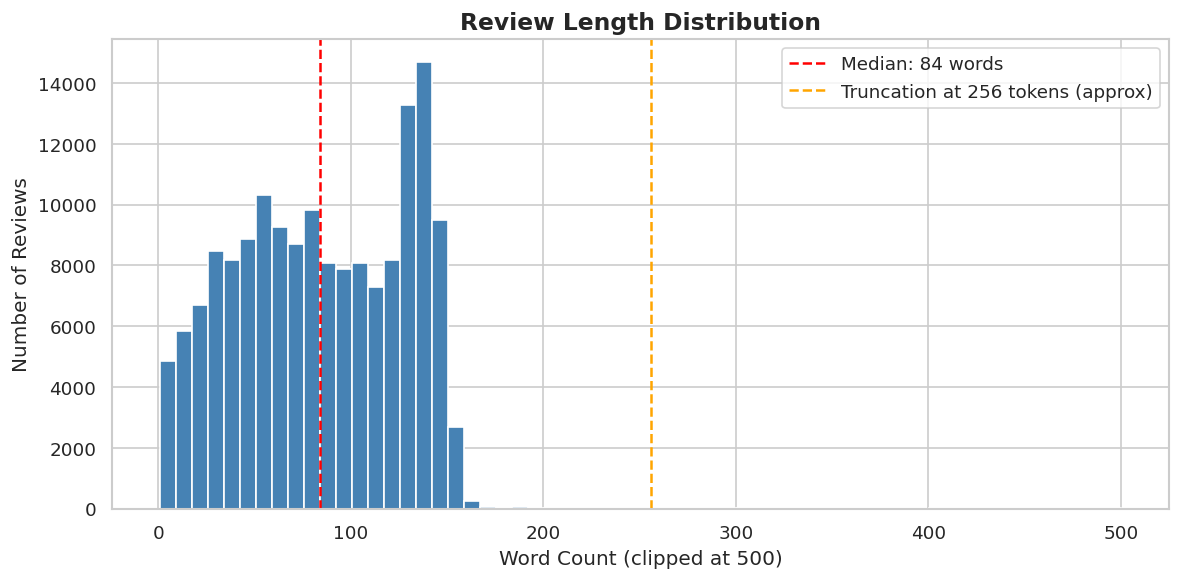

Saved: eda_review_lengths.png

Review length stats (words):
count    161297.0
mean         84.7
std          45.0
min           1.0
25%          48.0
50%          84.0
75%         126.0
max        1894.0
Name: word_count, dtype: float64

Reviews that would be truncated at 256 tokens: ~0.1%


In [11]:
train_df['word_count'] = train_df['review'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_df['word_count'].clip(upper=500), bins=60, color='steelblue', edgecolor='white')
ax.axvline(x=train_df['word_count'].median(), color='red', linestyle='--',
           label=f'Median: {train_df["word_count"].median():.0f} words')
ax.axvline(x=256, color='orange', linestyle='--', label='Truncation at 256 tokens (approx)')
ax.set_xlabel('Word Count (clipped at 500)', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Review Length Distribution', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nlp-project/eda_review_lengths.png', bbox_inches='tight')
plt.show()
print('Saved: eda_review_lengths.png')

print(f'\nReview length stats (words):')
print(train_df['word_count'].describe().round(1))
pct_truncated = (train_df['word_count'] > 256).mean() * 100
print(f'\nReviews that would be truncated at 256 tokens: ~{pct_truncated:.1f}%')

## 7. Sample Reviews per Condition

In [12]:
sample_conditions = ['Birth Control', 'Depression', 'Anxiety', 'ADHD', 'Acne']

for cond in sample_conditions:
    sample = valid[valid['condition'] == cond]['review'].iloc[0]
    clean = html.unescape(sample).strip('"').strip()[:300]
    print(f'\n--- {cond} ---')
    print(clean + ('...' if len(sample) > 300 else ''))


--- Birth Control ---
I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not available in US, so I switched to Lybrel, because the ingredients are similar. When my other pills ended, I ...

--- Depression ---
I have taken anti-depressants for years, with some improvement but mostly moderate to severe side affects, which makes me go off them.

I only take Cymbalta now mostly for pain.

When I began Deplin, I noticed a major improvement overnight. More energy, better disposition, and no sinking to the ...

--- Anxiety ---
Was on this med for 5 years. Worked fine but not great. Stopped the panic attacks and gave me relief of every day nervousness that I was experiencing. Took months for the side effects to diminish when I first started taking it. What did not leave - insomnia, night sweats, lack of sex drive and poor ...

--- ADHD ---
My son is halfway 

## 8. Final Top 20 Conditions List

This list will be used consistently across all modeling notebooks.

In [13]:
TOP_20_CONDITIONS = condition_counts.head(20).index.tolist()

print('TOP 20 CONDITIONS (in order of frequency):')
for i, c in enumerate(TOP_20_CONDITIONS, 1):
    count = condition_counts[c]
    print(f'{i:2}. {c:<45} {count:6,} reviews')

import json
with open('/content/drive/MyDrive/nlp-project/top20_conditions.json', 'w') as f:
    json.dump(TOP_20_CONDITIONS, f, indent=2)
print('\nSaved top20_conditions.json')

TOP 20 CONDITIONS (in order of frequency):
 1. Birth Control                                 28,788 reviews
 2. Depression                                     9,069 reviews
 3. Pain                                           6,145 reviews
 4. Anxiety                                        5,904 reviews
 5. Acne                                           5,588 reviews
 6. Bipolar Disorde                                4,224 reviews
 7. Insomnia                                       3,673 reviews
 8. Weight Loss                                    3,609 reviews
 9. Obesity                                        3,568 reviews
10. ADHD                                           3,383 reviews
11. Emergency Contraception                        2,463 reviews
12. High Blood Pressure                            2,321 reviews
13. Vaginal Yeast Infection                        2,274 reviews
14. Abnormal Uterine Bleeding                      2,096 reviews
15. Bowel Preparation                          

## Summary

**Key findings:**
- The dataset has ~160K training reviews across 884 unique conditions
- The distribution is highly skewed: Birth Control alone accounts for ~18% of reviews
- ~51% of conditions have fewer than 10 reviews — unsuitable for classification
- The top 20 conditions cover ~59.6% of the dataset
- Data quality issues: HTML entities in review text, malformed condition labels, 899 empty conditions

**Next step:** `02_biobert_classifier.ipynb` — Fine-tune BioBERT on the top 20 conditions